# Question 1: TF-IDF Vectorization
# Task: Convert the text data into a TF-IDF matrix and display the features.

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
documents = [
    "I love machine learning and NLP.",
    "TF-IDF is a popular method in text mining.",
    "Natural Language Processing is fascinating.",
    "I love learning new things in NLP."
]
tfidf = TfidfVectorizer(stop_words='english')
dtm = tfidf.fit_transform(documents)
print("TFIDF Matrix: \n",dtm.toarray())
print("Features: \n",tfidf.get_feature_names_out())

TFIDF Matrix: 
 [[0.         0.         0.         0.46580855 0.46580855 0.59081908
  0.         0.         0.         0.         0.46580855 0.
  0.         0.         0.         0.        ]
 [0.         0.40824829 0.         0.         0.         0.
  0.40824829 0.40824829 0.         0.         0.         0.40824829
  0.         0.40824829 0.40824829 0.        ]
 [0.5        0.         0.5        0.         0.         0.
  0.         0.         0.5        0.         0.         0.
  0.5        0.         0.         0.        ]
 [0.         0.         0.         0.40104275 0.40104275 0.
  0.         0.         0.         0.50867187 0.40104275 0.
  0.         0.         0.         0.50867187]]
Features: 
 ['fascinating' 'idf' 'language' 'learning' 'love' 'machine' 'method'
 'mining' 'natural' 'new' 'nlp' 'popular' 'processing' 'text' 'tf'
 'things']


In [2]:
dir(dtm)

['T',
 '__abs__',
 '__abstractmethods__',
 '__add__',
 '__array_priority__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__div__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__idiv__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__pow__',
 '__radd__',
 '__rdiv__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmatmul__',
 '__rmul__',
 '__round__',
 '__rsub__',
 '__rtruediv__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__weakref__',
 '_abc_impl',
 '_add_dense',
 '_add_sparse',
 '_allow_nd',
 '_argminmax',
 '_argminmax_axis',
 '_ascontainer'

# Question 2: CountVectorizer
# Task: Use CountVectorizer to find word frequency.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
texts = [
    "ChatGPT is an LLM model.",
    "ChatGPT is useful for NLP tasks.",
    "NLP involves working with language."
]
countervector = CountVectorizer(stop_words='english')
dtm = countervector.fit_transform(texts)
print("Countervector Matrix: \n",dtm.toarray())
print("Features: \n",countervector.get_feature_names_out())

Countervector Matrix: 
 [[1 0 0 1 1 0 0 0 0]
 [1 0 0 0 0 1 1 1 0]
 [0 1 1 0 0 1 0 0 1]]
Features: 
 ['chatgpt' 'involves' 'language' 'llm' 'model' 'nlp' 'tasks' 'useful'
 'working']


# Question 3: Topic Modeling using LDA
# Task: Apply Latent Dirichlet Allocation (LDA) to find topics from the text.

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
documents = [
    "Data science is an interdisciplinary field.",
    "Artificial intelligence and machine learning are part of data science.",
    "Natural language processing helps computers understand text.",
    "Deep learning is useful in image and text processing."
]
countervector = CountVectorizer(stop_words='english')
dtm = countervector.fit_transform(documents)

lda_model = LatentDirichletAllocation(n_components = 2)
lda_model.fit(dtm)
for index,topic in enumerate (lda_model.components_):
    results = ([countervector.get_feature_names_out()[i] for i in topic.argsort()[-5:]])
    print(results)

['artificial', 'intelligence', 'machine', 'data', 'science']
['deep', 'useful', 'learning', 'processing', 'text']


# Question 4: Sentiment Analysis using VADER
# Task: Analyze sentiment of given text reviews.

In [5]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sentences = [
    "I love the new feature, it's amazing!",
    "This update is terrible and frustrating.",
    "The service was okay, not the best.",
    "I’m so happy with the experience!",
    "Very disappointed. Will not recommend."
]
sid = SentimentIntensityAnalyzer()
for text in sentences:
    senti = sid.polarity_scores(text)
    print(f"{text} -- {senti}")

I love the new feature, it's amazing! -- {'neg': 0.0, 'neu': 0.325, 'pos': 0.675, 'compound': 0.8516}
This update is terrible and frustrating. -- {'neg': 0.6, 'neu': 0.4, 'pos': 0.0, 'compound': -0.7184}
The service was okay, not the best. -- {'neg': 0.328, 'neu': 0.487, 'pos': 0.185, 'compound': -0.3544}
I’m so happy with the experience! -- {'neg': 0.0, 'neu': 0.539, 'pos': 0.461, 'compound': 0.6468}
Very disappointed. Will not recommend. -- {'neg': 0.647, 'neu': 0.353, 'pos': 0.0, 'compound': -0.6708}


# Question 5: Generate a Word Cloud
# Task: Generate a word cloud from the input text.

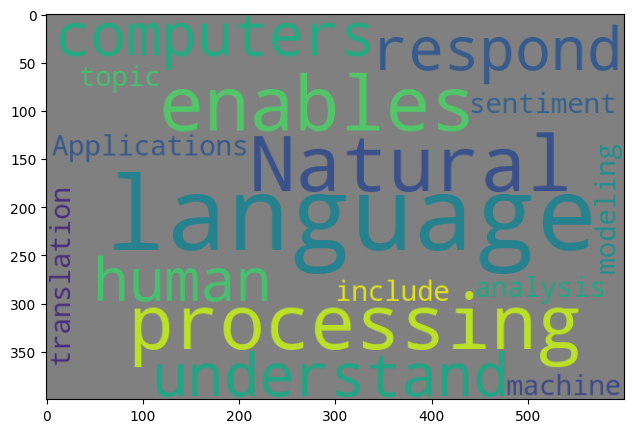

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = """
Natural language processing enables computers to understand and respond to human language.
Applications include sentiment analysis, machine translation, and topic modeling.
"""

wordcloud = WordCloud(width=600, height=400, background_color='grey').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis("on")
plt.show()
